In [44]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import random
import re
from scipy.stats import ttest_rel
from tqdm.auto import tqdm
from matplotlib.lines import Line2D

# --- Visual Configuration ---
sns.set_theme(style="whitegrid")
seed = 42
np.random.seed(seed)
random.seed(seed)

plt.rcParams.update({
    "text.usetex": False,                 
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",             
    "mathtext.rm": "serif",
    "axes.labelsize": 34,
    "axes.titlesize": 30,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 20
})

# --- Label Mappings ---
label_map_csv_to_key = {
    'DiRoCA (eps_0.5_delta_0.5)': 'DIROCA_0.5',
    'DiRoCA (eps_1.0_delta_1.0)': 'DIROCA_1',
    'DiRoCA (eps_2.0_delta_2.0)': 'DIROCA_2',
    'DiRoCA (eps_4.0_delta_4.0)': 'DIROCA_4',
    'DiRoCA (eps_8.0_delta_8.0)': 'DIROCA_8',
    'GradCA': 'GradCA',
    'BaryCA': 'BARYCA',
    'Abs-LiNGAM (Perfect)': 'Abslin_p',
    'Abs-LiNGAM (Noisy)': 'Abslin_n'
}

print_label_map = {
    'DIROCA_0.5':   r'DiRoCA$_{0.5,0.5}$',
    'DIROCA_1':     r'DiRoCA$_{1,1}$',
    'DIROCA_2':     r'DiRoCA$_{2,2}$',
    'DIROCA_4':     r'DiRoCA$_{4,4}$',
    'DIROCA_8':     r'DiRoCA$_{8,8}$',
    'GradCA':       r'GRAD$_{(\tau, \omega)}$',
    'BARYCA':       r'BARY$_{(\tau, \omega)}$',
    'Abslin_p':     r'AbsLin$_{\text{p}}$', 
    'Abslin_n':     r'AbsLin$_{\text{n}}$'
}

color_map = {
    r'DiRoCA$_{0.5,0.5}$': '#17becf',
    r'DiRoCA$_{1,1}$': 'gold',
    r'DiRoCA$_{2,2}$': 'darkorange',
    r'DiRoCA$_{4,4}$': 'lightskyblue',
    r'DiRoCA$_{8,8}$': 'violet',
    r'GRAD$_{(\tau, \omega)}$': '#2ca02c',                  
    r'BARY$_{(\tau, \omega)}$': '#d62728',                     
    r'AbsLin$_{\text{p}}$': '#9467bd',                       
    r'AbsLin$_{\text{n}}$': '#8c564b'                       
}

display_order = [
    r'DiRoCA$_{0.5,0.5}$', r'DiRoCA$_{1,1}$', r'DiRoCA$_{2,2}$', 
    r'DiRoCA$_{4,4}$', r'DiRoCA$_{8,8}$',
    r'GRAD$_{(\tau, \omega)}$', r'BARY$_{(\tau, \omega)}$', 
    r'AbsLin$_{\text{p}}$', r'AbsLin$_{\text{n}}$'
]

def generate_significance_table(df, title_suffix):
    """
    Generates a table with Mean, Std, and Significance markers (paired t-test).
    """
    pivot = df.pivot_table(index=['fold', 'trial'], columns='display_name', values='error')
    
    if pivot.empty:
        print(f" No paired data available for {title_suffix}")
        return

    # Identify Best Method
    means = pivot.mean()
    best_method = means.idxmin()
    best_series = pivot[best_method]
    
    print(f"\n{title_suffix}")
    print(f"   Best Method (Ref): {best_method} (Error={means[best_method]:.4f})")
    print("-" * 75)
    print(f"{'Method':<30} | {'Mean ± Std':<20} | {'Sig.'}")
    print("-" * 75)
    
    for method in display_order:
        if method not in pivot.columns: continue
        
        series = pivot[method]
        mean_val = series.mean()
        std_val = series.std()
        
        sig_mark = ""
        if method == best_method:
            sig_mark = "(Ref)"
        else:
            common_idx = best_series.dropna().index.intersection(series.dropna().index)
            if len(common_idx) > 1:
                _, p_val = ttest_rel(best_series.loc[common_idx], series.loc[common_idx])
                if p_val < 0.001: sig_mark = "***"
                elif p_val < 0.01: sig_mark = "**"
                elif p_val < 0.05: sig_mark = "*"
                else: sig_mark = "ns"
        
        print(f"{method:<30} | {mean_val:>6.2f} ± {std_val:<6.2f} | {sig_mark}")
    print("-" * 75 + "\n")

In [45]:
def load_protocol_a_data(distribution):
    """
    Loads the latest result file for a specific distribution 
    in 'standard' mode (Protocol A: Generalization).
    """
    base_dir = "data/lucas/evaluation_results"
    pattern = f"{base_dir}/empirical_evaluation_*_{distribution}_mode_standard_*.csv"
    files = sorted(glob.glob(pattern), key=os.path.getmtime)
    
    if not files:
        print(f"No Protocol A data found for {distribution}"); return None
    
    latest_file = files[-1]
    print(f"Loading {distribution.capitalize()}: {os.path.basename(latest_file)}")
    
    df = pd.read_csv(latest_file)
    df['method_key'] = df['method'].map(label_map_csv_to_key)
    df = df.dropna(subset=['method_key']) 
    df['display_name'] = df['method_key'].map(print_label_map)
    return df

def load_protocol_b_data(distribution):
    """
    Loads the latest result file for a specific distribution 
    in Protocol B: Consistency.
    """
    base_dir = "data/lucas/evaluation_results"
    pattern = f"{base_dir}/empirical_evaluation_*_{distribution}_mode_counterfactual_*.csv"
    files = sorted(glob.glob(pattern), key=os.path.getmtime)
    
    if not files:
        print(f"No Protocol B data found for {distribution}"); return None
    
    latest_file = files[-1]
    print(f"Loading {distribution.capitalize()}: {os.path.basename(latest_file)}")
    
    df = pd.read_csv(latest_file)
    df['method_key'] = df['method'].map(label_map_csv_to_key)
    df = df.dropna(subset=['method_key']) 
    df['display_name'] = df['method_key'].map(print_label_map)
    return df

In [46]:
def plot_robustness_panel_a(df, distribution_name, y_limit=None):
    if df is None: return

    # Get Max Noise and Max Alpha
    max_noise = df['noise_scale'].max()
    max_alpha = df['alpha'].max()
    
    # Filter Data
    df_alpha_plot = df[np.isclose(df['noise_scale'], max_noise)].copy()
    df_sigma_plot = df[np.isclose(df['alpha'], max_alpha)].copy()

    present_methods = set(df_alpha_plot['display_name'].unique()) | set(df_sigma_plot['display_name'].unique())

    fig, axes = plt.subplots(1, 2, figsize=(24, 10))
    fig.suptitle(f"{distribution_name} (Protocol A: Generalization)", fontsize=36, y=1.05)
    
    # --- Plot A: Vary Alpha ---
    ax_a = axes[0]
    sns.lineplot(
        data=df_alpha_plot, x='alpha', y='error',
        hue='display_name', hue_order=display_order, palette=color_map,
        style='display_name', style_order=display_order,
        markers=True, dashes=False, markersize=12, linewidth=3.5,
        errorbar='sd', ax=ax_a, legend=False
    )
    
    ax_a.set_xlabel(r'$\alpha$', fontsize=34)
    ax_a.set_ylabel('Abstraction Error', fontsize=34)
    ax_a.grid(True, linestyle='--', alpha=0.7)
    if y_limit: ax_a.set_ylim(0, y_limit)

    # --- Plot B: Vary Sigma ---
    ax_b = axes[1]
    sns.lineplot(
        data=df_sigma_plot, x='noise_scale', y='error',
        hue='display_name', hue_order=display_order, palette=color_map,
        style='display_name', style_order=display_order,
        markers=True, dashes=False, markersize=12, linewidth=3.5,
        errorbar='sd', ax=ax_b, legend=False
    )
    
    ax_b.set_xlabel(r'$\tilde{\sigma}$', fontsize=34)
    ax_b.set_ylabel('', fontsize=34)
    ax_b.grid(True, linestyle='--', alpha=0.7)
    if y_limit: ax_b.set_ylim(0, y_limit)

    legend_handles = []
    legend_labels = []
    
    for lbl in display_order:
        if lbl in present_methods:
            handle = Line2D([0], [0], color=color_map[lbl], linewidth=3.5, marker='o', markersize=12)
            legend_handles.append(handle)
            legend_labels.append(lbl)

    if legend_handles:
        fig.legend(
            legend_handles, legend_labels,
            loc='lower center', bbox_to_anchor=(0.5, -0.15),
            ncol=5, fontsize=24, frameon=False, columnspacing=1.5
        )

    plt.tight_layout()
    plt.show()
    
    df_clean = df[df['alpha'] == 0.0]
    generate_significance_table(df_clean, f"CLEAN (α=0) - {distribution_name} [Generalization]")
    
    df_shifted = df[(df['alpha'] == 1.0) & (np.isclose(df['noise_scale'], max_noise))]
    generate_significance_table(df_shifted, f"SHIFTED (α=1, σ={max_noise}) - {distribution_name} [Generalization]")

def plot_robustness_panel_b(df, distribution_name, y_limit=None):
    if df is None: return

    # Get Max Noise and Max Alpha
    max_noise = df['noise_scale'].max()
    max_alpha = df['alpha'].max()
    
    # Filter Data
    df_alpha_plot = df[np.isclose(df['noise_scale'], max_noise)].copy()
    df_sigma_plot = df[np.isclose(df['alpha'], max_alpha)].copy()

    present_methods = set(df_alpha_plot['display_name'].unique()) | set(df_sigma_plot['display_name'].unique())

    fig, axes = plt.subplots(1, 2, figsize=(24, 10))
    fig.suptitle(f"{distribution_name} (Protocol B: Consistency)", fontsize=36, y=1.05)
    
    # --- Plot A: Vary Alpha ---
    ax_a = axes[0]
    sns.lineplot(
        data=df_alpha_plot, x='alpha', y='error',
        hue='display_name', hue_order=display_order, palette=color_map,
        style='display_name', style_order=display_order,
        markers=True, dashes=False, markersize=12, linewidth=3.5,
        errorbar='sd', ax=ax_a, legend=False
    )
    
    ax_a.set_title(rf"Vary $\alpha$ (Fixed $\tilde{{\sigma}}={max_noise}$)", fontsize=30)
    ax_a.set_xlabel(r'$\alpha$', fontsize=34)
    ax_a.set_ylabel('Abstraction Error', fontsize=34)
    ax_a.grid(True, linestyle='--', alpha=0.7)
    if y_limit: ax_a.set_ylim(0, y_limit)

    # --- Plot B: Vary Sigma ---
    ax_b = axes[1]
    sns.lineplot(
        data=df_sigma_plot, x='noise_scale', y='error',
        hue='display_name', hue_order=display_order, palette=color_map,
        style='display_name', style_order=display_order,
        markers=True, dashes=False, markersize=12, linewidth=3.5,
        errorbar='sd', ax=ax_b, legend=False
    )
    
    ax_b.set_title(rf"Vary $\tilde{{\sigma}}$ (Fixed $\alpha={max_alpha}$)", fontsize=30)
    ax_b.set_xlabel(r'$\tilde{\sigma}$', fontsize=34)
    ax_b.set_ylabel('', fontsize=34)
    ax_b.grid(True, linestyle='--', alpha=0.7)
    if y_limit: ax_b.set_ylim(0, y_limit)

    legend_handles = []
    legend_labels = []
    
    for lbl in display_order:
        if lbl in present_methods:
            handle = Line2D([0], [0], color=color_map[lbl], linewidth=3.5, marker='o', markersize=12)
            legend_handles.append(handle)
            legend_labels.append(lbl)

    if legend_handles:
        fig.legend(
            legend_handles, legend_labels,
            loc='lower center', bbox_to_anchor=(0.5, -0.15),
            ncol=5, fontsize=24, frameon=False, columnspacing=1.5
        )

    plt.tight_layout()
    plt.show()
    
    df_clean = df[df['alpha'] == 0.0]
    generate_significance_table(df_clean, f"CLEAN (α=0) - {distribution_name} [Consistency]")
    
    df_shifted = df[(df['alpha'] == 1.0) & (np.isclose(df['noise_scale'], max_noise))]
    generate_significance_table(df_shifted, f"SHIFTED (α=1, σ={max_noise}) - {distribution_name} [Consistency]")

Loading Gaussian: empirical_evaluation_additive_gaussian_mode_standard_alpha10_noise20_trials20_20251215_180452.csv


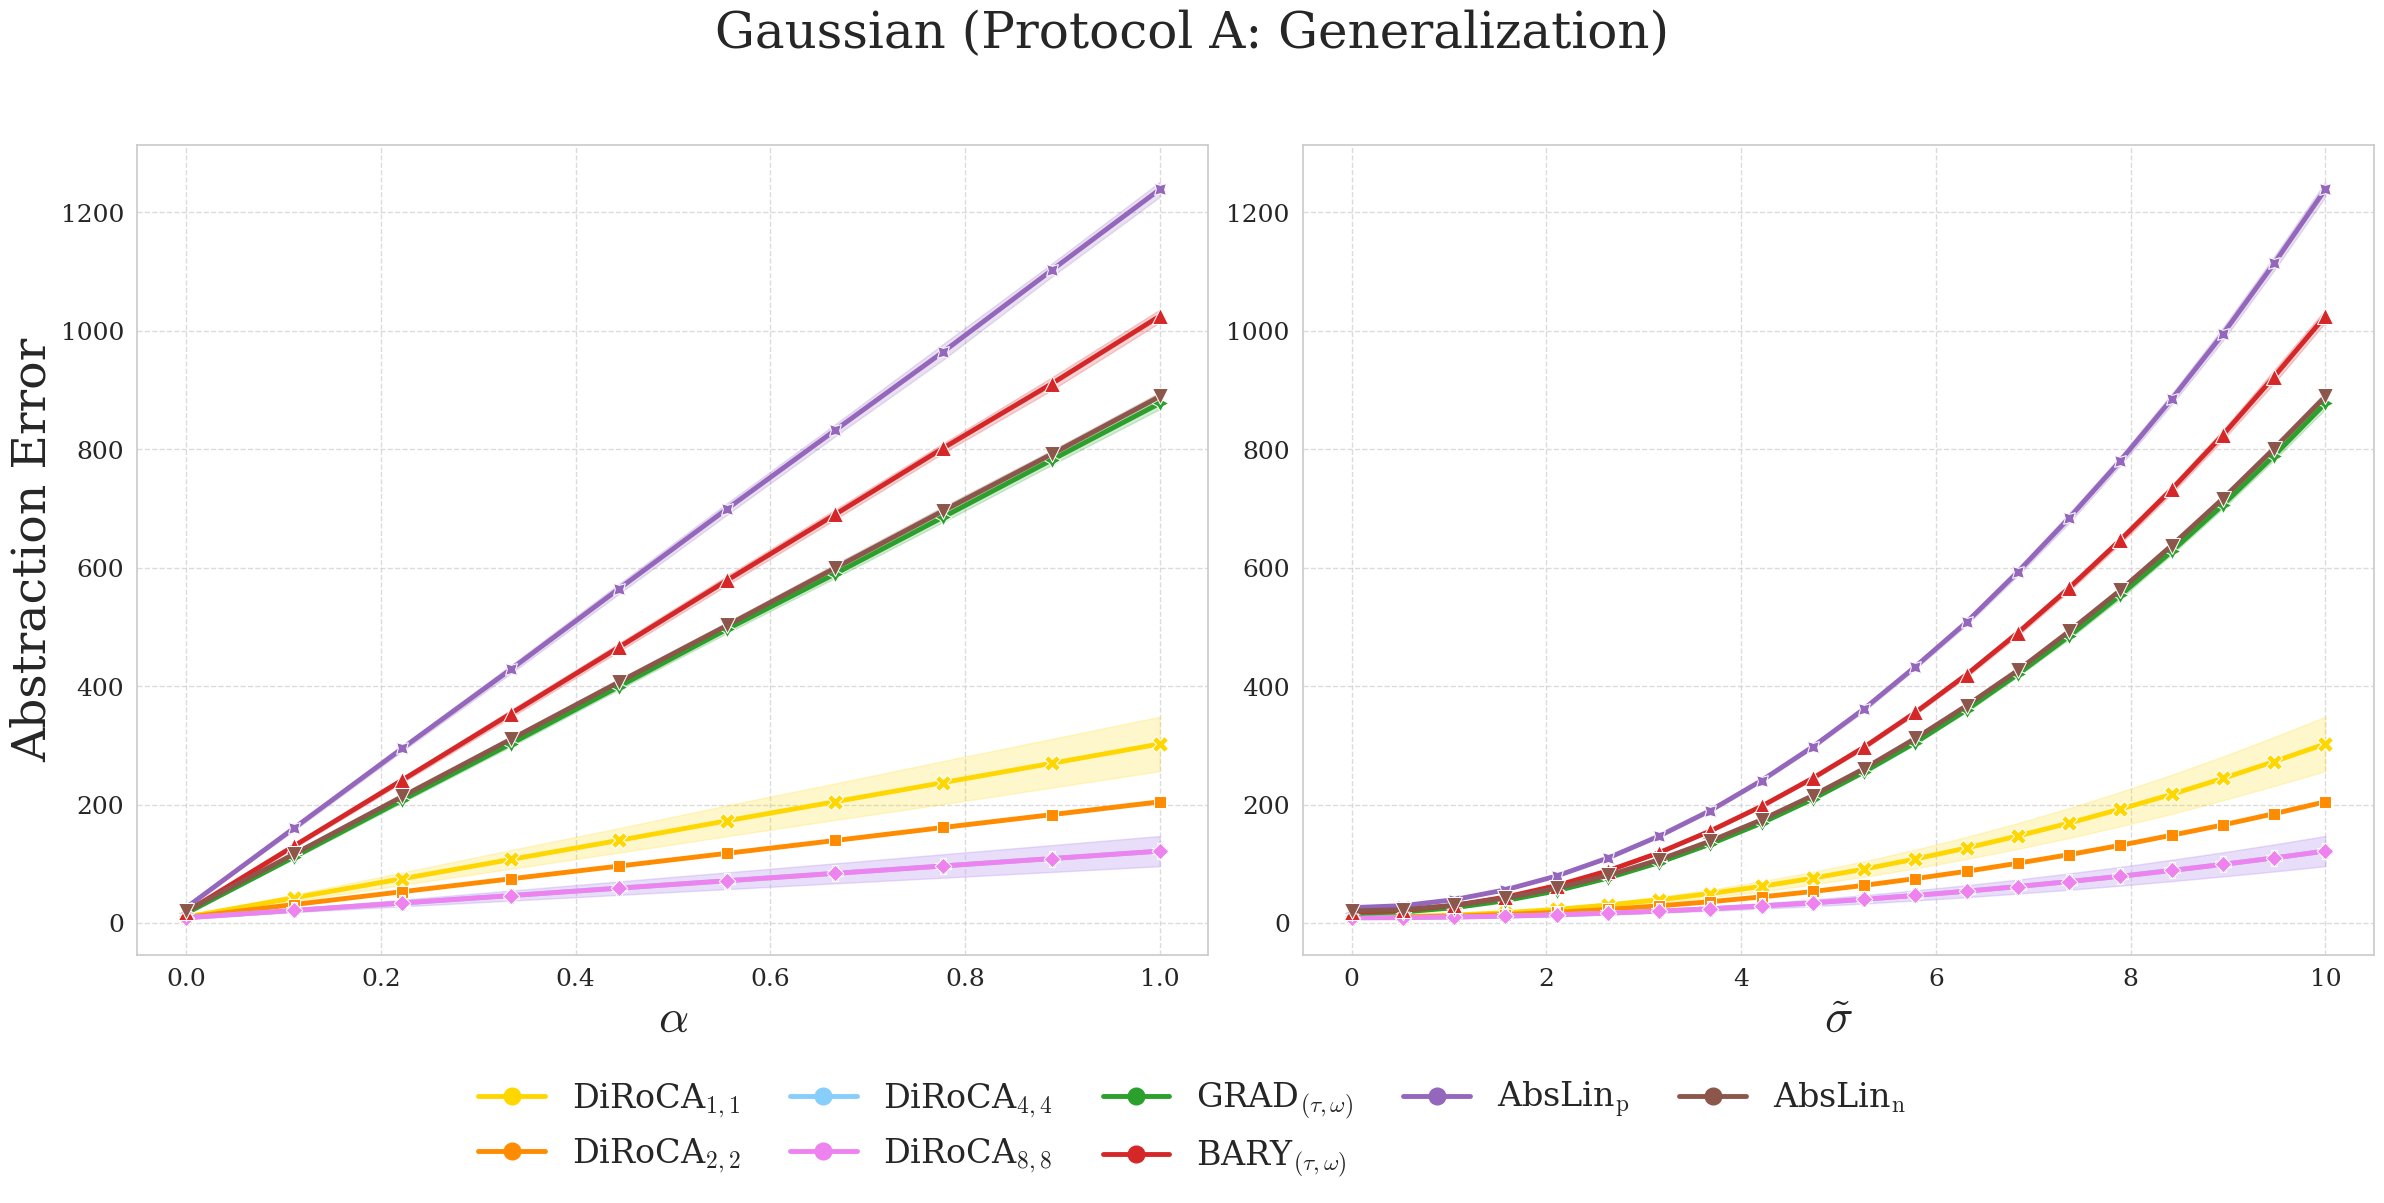


CLEAN (α=0) - Gaussian [Generalization]
   Best Method (Ref): DiRoCA$_{4,4}$ (Error=8.9772)
---------------------------------------------------------------------------
Method                         | Mean ± Std           | Sig.
---------------------------------------------------------------------------
DiRoCA$_{1,1}$                 |  10.27 ± 0.53   | ***
DiRoCA$_{2,2}$                 |   9.67 ± 0.11   | ***
DiRoCA$_{4,4}$                 |   8.98 ± 0.10   | (Ref)
DiRoCA$_{8,8}$                 |   8.98 ± 0.10   | ***
GRAD$_{(\tau, \omega)}$        |  16.39 ± 0.13   | ***
BARY$_{(\tau, \omega)}$        |  18.74 ± 0.11   | ***
AbsLin$_{\text{p}}$            |  26.09 ± 0.19   | ***
AbsLin$_{\text{n}}$            |  20.36 ± 0.14   | ***
---------------------------------------------------------------------------


SHIFTED (α=1, σ=10.0) - Gaussian [Generalization]
   Best Method (Ref): DiRoCA$_{8,8}$ (Error=121.5384)
----------------------------------------------------------------------

In [47]:
df_gaussian = load_protocol_a_data("gaussian")
plot_robustness_panel_a(df_gaussian, "Gaussian")

# ω-misspecification

In [48]:
def run_omega_analysis_protocol_a(distribution="gaussian", num_trials=10):
    # 1. Load Data 
    pack_path = "data/lucas/lucas_pack.pkl"
    if not os.path.exists(pack_path): print("Pack not found"); return
    pack = joblib.load(pack_path)
    omega_map = pack["omega"]

    # 2. Load Results
    base_dir = "data/lucas/results_nonlinear"
    pkl_files = glob.glob(os.path.join(base_dir, "*_cv_results_empirical.pkl"))
    
    ref_data = joblib.load(pkl_files[0])
    saved_folds = []
    first_key = next(iter(ref_data.keys()))
    if "test_indices" in ref_data[first_key]: # Flat
        for k, v in ref_data.items():
            if "fold_" in k: saved_folds.append({"id": int(k.split("_")[1]), "test": v["test_indices"]})
    else: # Nested
        first_run = next(iter(ref_data[first_key].keys()))
        for k, v in ref_data.items():
            if "fold_" in k: saved_folds.append({"id": int(k.split("_")[1]), "test": v[first_run]["test_indices"]})

    records = []
    print(f"Running Omega Misspecification (Protocol A: Generalization)...")
    
    for trial in tqdm(range(num_trials), desc="Trials"):
        # Corrupt Omega
        corrupt_omega = omega_map.copy()
        keys = list(omega_map.keys()); vals = list(omega_map.values())
        random.shuffle(keys)
        for i, k in enumerate(keys): corrupt_omega[k] = vals[i]

        for pkl in pkl_files:
            data = joblib.load(pkl)
            fname = os.path.basename(pkl)
            
            for fold in saved_folds:
                fk = f"fold_{fold['id']}"
                if fk not in data: continue
                
                content = data[fk]
                if "T_matrix" in content: runs = {fname: content}
                else: runs = content
                
                test_idx = fold["test"]
                
                for run_id, res in runs.items():
                    T = res.get("T_matrix", res.get("T"))
                    if T is None: continue
                    
                    errs = []
                    for iota in omega_map:
                        wrong_eta = corrupt_omega[iota]
                        if iota not in pack['ll'] or wrong_eta not in pack['hl']: continue
                        
                        X_L = pack['ll'][iota]['X'][test_idx]
                        X_H = pack['hl'][wrong_eta]['X'][test_idx]
                        
                        X_pred = X_L @ T.T
                        e = np.linalg.norm(X_pred - X_H, ord='fro')**2 / (X_pred.shape[0]*X_pred.shape[1])
                        errs.append(e)
                    
                    if not errs: continue
                    
                    name = "Unknown"
                    if "gradca" in fname: name = 'GradCA'
                    elif "baryca" in fname: name = 'BaryCA'
                    elif "abslingam" in fname: 
                        name = 'Abs-LiNGAM (Perfect)' if 'Perfect' in run_id else 'Abs-LiNGAM (Noisy)'
                    elif "diroca" in fname:
                        match = re.search(r"eps_([\d\.]+)", str(run_id))
                        if match: 
                            eps = match.group(1)
                            name = f"DiRoCA (eps_{eps}_delta_{eps})"
                        
                    mapped = label_map_csv_to_key.get(name, name)
                    display = print_label_map.get(mapped, mapped)
                    
                    records.append({
                        "display_name": display,
                        "fold": fold['id'],
                        "trial": trial,
                        "error": np.mean(errs)
                    })

    df_omega = pd.DataFrame(records)
    generate_significance_table(df_omega, f"OMEGA MISSPECIFICATION - {distribution}")

run_omega_analysis_protocol_a("gaussian")

Running Omega Misspecification (Protocol A: Generalization)...


Trials:   0%|          | 0/10 [00:00<?, ?it/s]


OMEGA MISSPECIFICATION - gaussian
   Best Method (Ref): DiRoCA$_{8,8}$ (Error=9.1155)
---------------------------------------------------------------------------
Method                         | Mean ± Std           | Sig.
---------------------------------------------------------------------------
DiRoCA$_{1,1}$                 |  11.36 ± 0.86   | ***
DiRoCA$_{2,2}$                 |  10.12 ± 0.27   | ***
DiRoCA$_{4,4}$                 |   9.12 ± 0.29   | ns
DiRoCA$_{8,8}$                 |   9.12 ± 0.29   | (Ref)
GRAD$_{(\tau, \omega)}$        |  18.48 ± 1.15   | ***
BARY$_{(\tau, \omega)}$        |  21.19 ± 1.35   | ***
AbsLin$_{\text{p}}$            |  29.07 ± 1.62   | ***
AbsLin$_{\text{n}}$            |  22.55 ± 1.13   | ***
---------------------------------------------------------------------------

